<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h1>Breast Cancer data cleaning</h1>
</div>

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h2>What is this notebook doing </h2>
    <p>
    - Loads data<br>
    - Cleans data<br>
    - Splits<br>
    - Saves splits in `data/data_clean`<br>
    </p>
</div>

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h1>Import procedure</h1>
    <p>
    1) Download data :<br>
    https://drive.google.com/file/d/1itXdRo4WJuhqCjtVX4WGvT327WWp4LB7/view?usp=sharing
    </p>
    <p>
    2) Save data in a subfolder called `data/raw_data` located at the project root</p>
</div>

In [4]:
# import os
# import re
# import unicodedata

from pathlib import Path

import chardet

# import matplotlib.pyplot as plt
# import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from building_perceptron.eda_utils import (
    count_duplicates,
    empty_columns,
    missing_like_columns,
    plot_numeric_histograms,
    plot_qualitative,
)



In [5]:
# current directory
ROOT_DIR = Path(".")
# absolute path
print(ROOT_DIR.resolve())

/home/coule/Documents/projets/building-perceptron


In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# DATA_DIR = ROOT_DIR / "data"
# RAW_DATA_DIR = DATA_DIR / "raw_data"
# DATA = RAW_DATA_DIR / "bcw_data.csv"
# CLEAN_DATA_DIR = DATA_DIR / "clean_data"
# TARGET = 'diagnosis'
from building_perceptron.config import ROOT_DIR, DATA_DIR, CLEAN_DATA_DIR, DATA, TARGET

In [7]:
print(CLEAN_DATA_DIR.resolve())

/home/coule/Documents/projets/building-perceptron/data/clean_data


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>Source file encoding format detection</p>
    <p>'encoding': 'ascii'</p>
</div>

In [8]:
with open(DATA, 'rb') as file :
    encodage = chardet.detect(file.read(10000))

print(encodage)

{'encoding': 'ascii', 'confidence': 1.0, 'language': 'eo', 'mime_type': 'text/plain'}


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>Import the source file with the proper encoding</p>
</div>

In [ ]:
pd.options.display.max_columns = None
df = pd.read_csv(DATA, encoding='ascii')

In [10]:
df.head(1)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,NaN


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>The 'id' columns contains only unique values, therefore it can be used as index column</p>
</div>

In [11]:
print(f"Duplicates in the   'id': {df['id'].duplicated().sum()}")
# print(f"Duplicates in the index: {df.index.duplicated().sum()}")

Duplicates in the   'id': 0


In [12]:
df = pd.read_csv(DATA, index_col=['id'])

df.head(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h3>How is the data before processing ?</h3>
    <p>No duplicates<br>
    The variable 'Unnamed: 32' is entierly empty, It thas to be removed<br>
    The other columns are NA free</p>
</div>

In [13]:
if count_duplicates(df) == 0:
    print("No duplicate found in the DataFrame.")
else :
    print(f"Number of duplicates found: {count_duplicates(df)}\nCall the duplicate_rows() function.")

No duplicate found in the DataFrame.


In [14]:
empty_columns(df)

['Unnamed: 32']

In [15]:
# Deletes the column ['Unnamed: 32'] (column on which every value is missing)
df = df.dropna(axis=1, how='all')

In [16]:
# No columns containing explicit missing values : NaN, None, '', 'na', 'null'
missing_like_columns(df)

[]

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h3>Descriptive Statistiques</h3>
    <p>For every variables, information is present on a large number of decimals<br>
    but the dataset has only 569 observations<br>
    Therefore it is not usefull to downsize `float64` into `float 32` or `float16`</p>
</div>

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-nu

In [18]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h3>No variables with a single value (single modalitity)</h3>
</div>

In [19]:
# Detection of variables which have only one category
# NaN being considered as a category .....  (dropna=False)
unique_value_cols = df.columns[df.nunique(dropna=False)==1].tolist()
unique_value_cols

[]

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h3>Numerical Variables</h3>
</div>

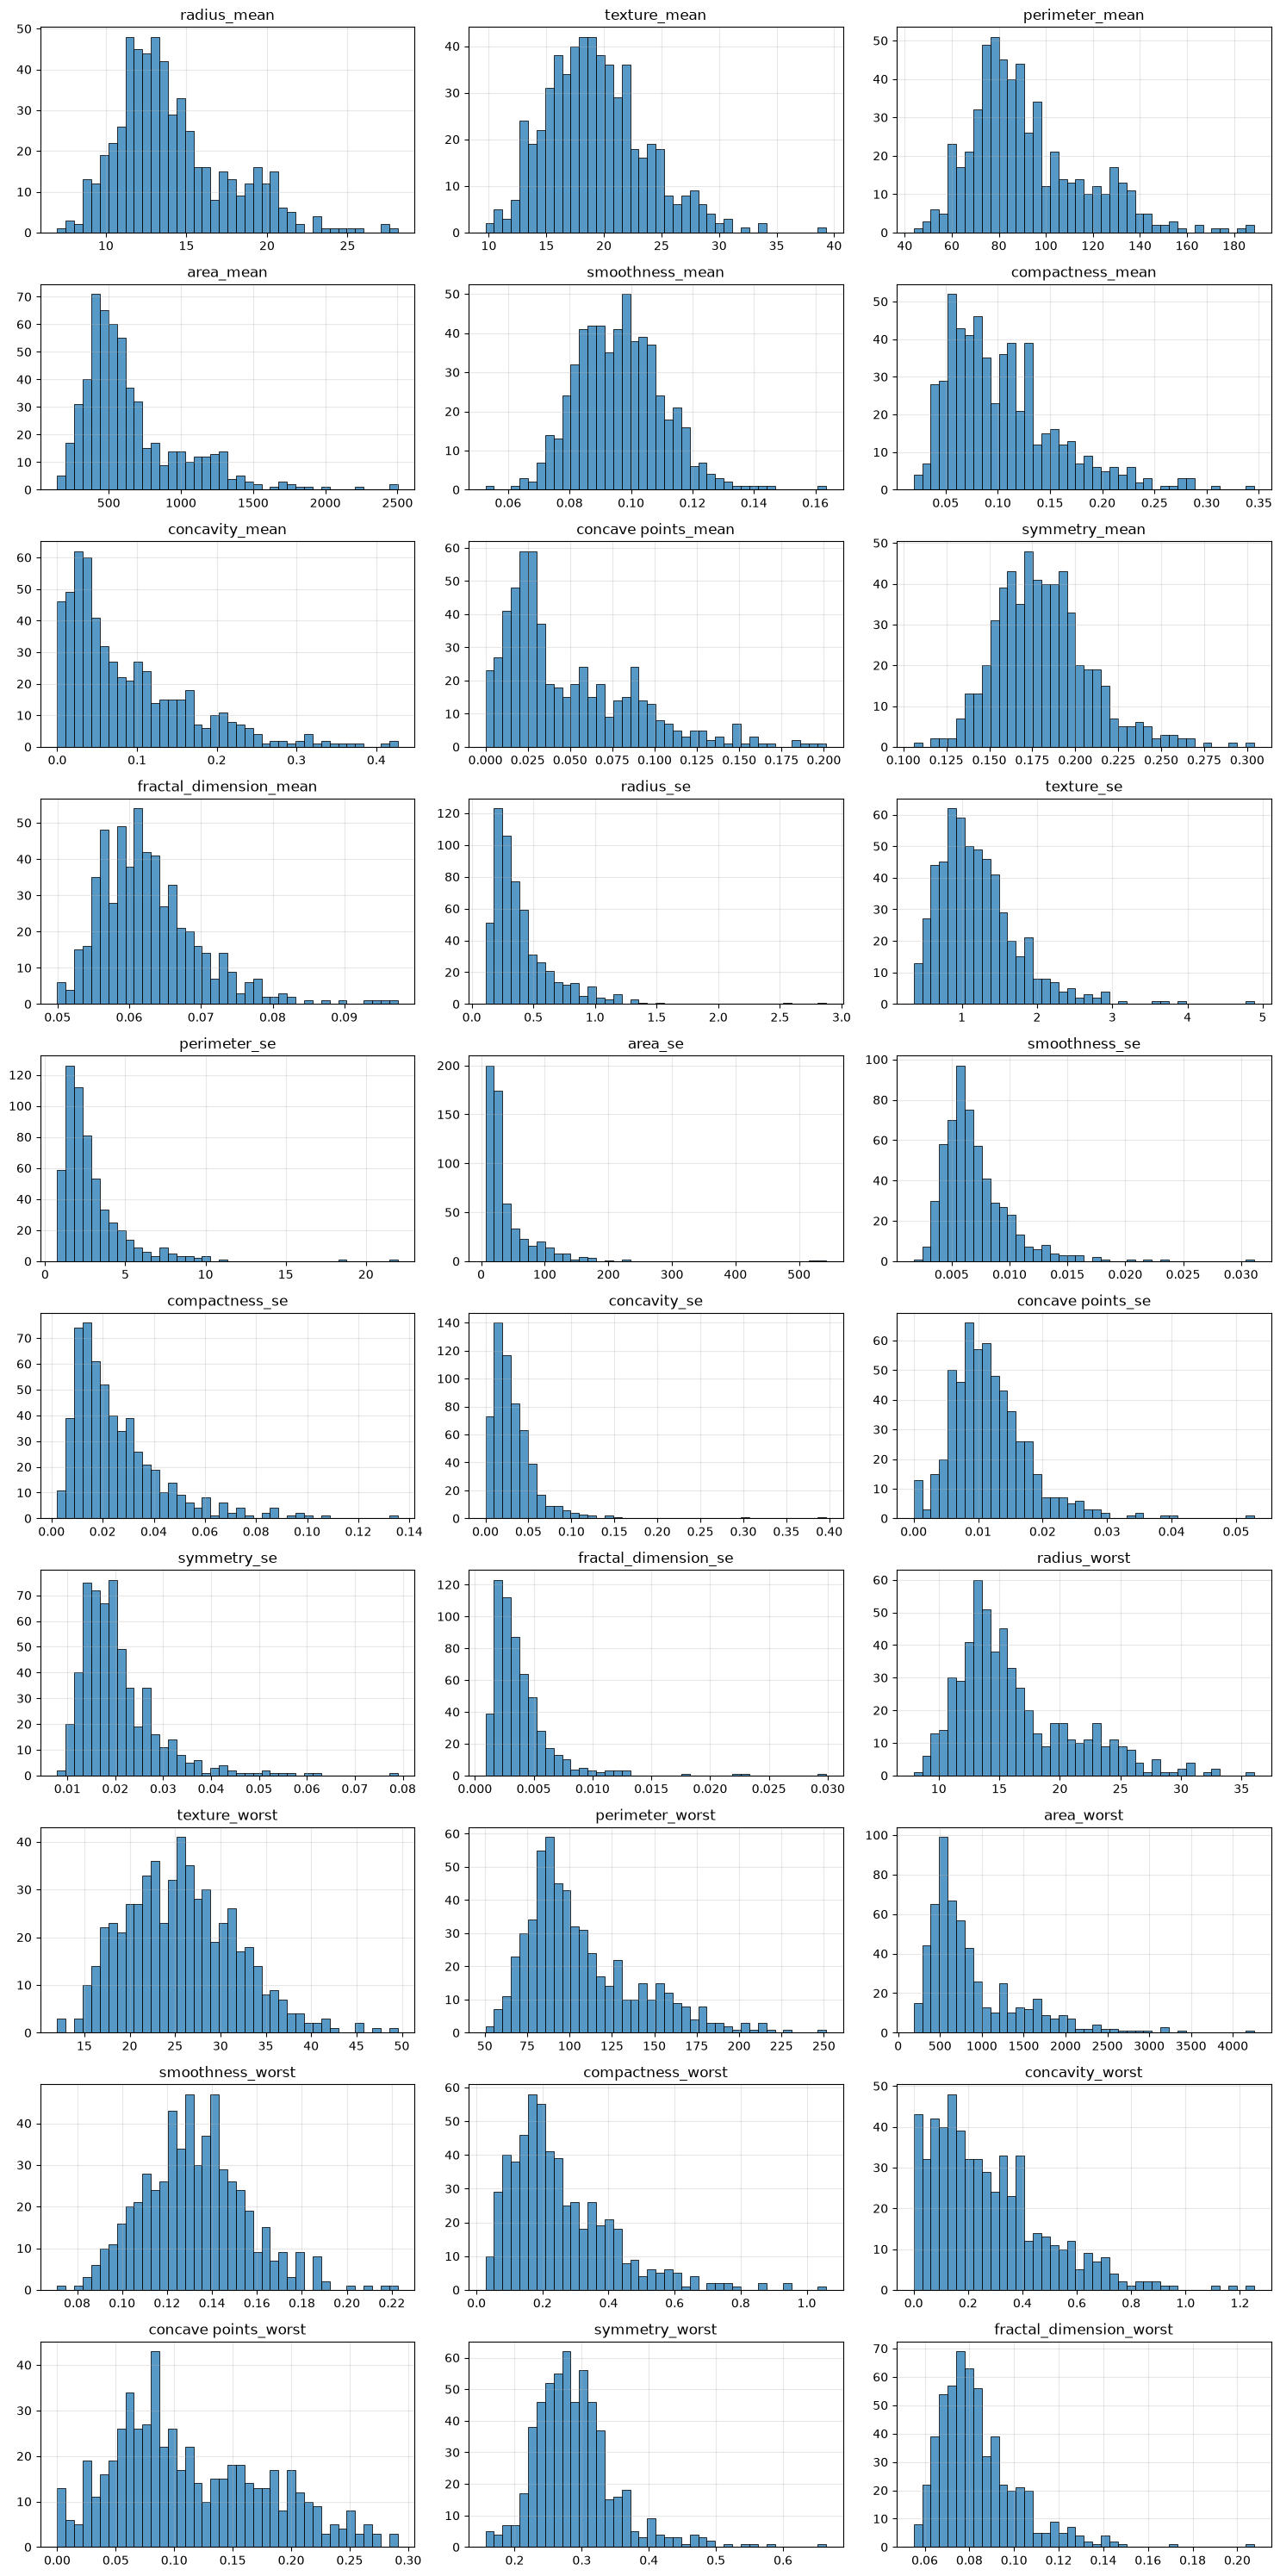

In [20]:
plot_numeric_histograms(df, bins=40, n_cols=3)

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h3>The only qualitative variable is also the target</h3>
    <p>The dataset is unbalanced, <strong>stratification is required during the train/test split</strong>
 </p>
</div>

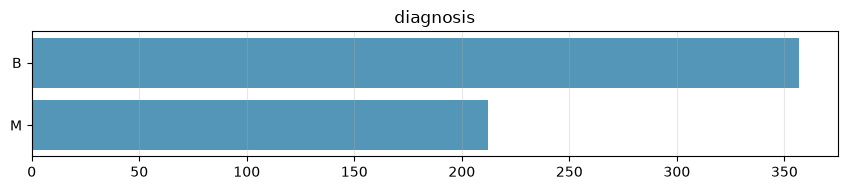

In [21]:
plot_qualitative(df, n_cols=3, figsize=(25, 2))

In [22]:

pourcentage_m = (df[TARGET].eq("M").mean()) * 100
print(f"M percentage : {pourcentage_m:.2f}%  (class 1)")

M percentage : 37.26%  (class 1)


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h4 style="margin: auto; padding: 20px; color: #439cc8; ">Target encodint into int</h4>
<ul>
<li style="margin: auto; color: #439cc8; ">"B" = classe 0 = 0</li>
<li style="margin: auto; color: #439cc8; ">"M" = classe 1 = 1</li>
</div>

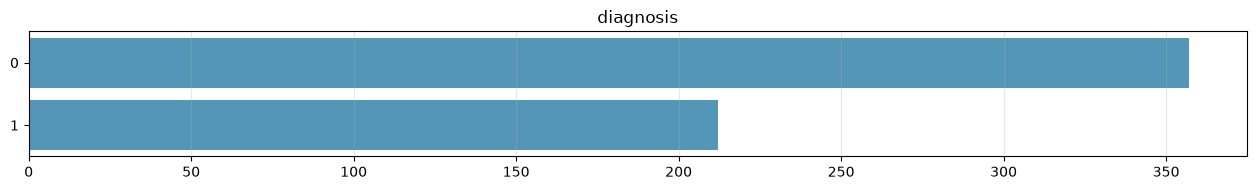

Class 1 percentage : 37.26%


In [23]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

plot_qualitative(df[TARGET].astype("category"), n_cols=2, figsize=(25, 2))

# Pourcentage de "1" sur l'ensemble des observations
pourcentage_1 = (df[TARGET].eq(1).mean()) * 100
print(f"Class 1 percentage : {pourcentage_1:.2f}%")

<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
<h3>Split Features / Target</h3>
</div>

In [24]:
# Features / Target split
y = df[TARGET]
X = df.drop(columns=[TARGET])

<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
<h3>Train / Test Split</h3>
<p>To avoid data leakage, the split is done first thing after structural cleaning<br>
Learned transformations will always be train-set based
<p>The split is stratified : <strong>train_set is as unbalanced as the original dataset </strong>
</div>

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"=== Train set ===\nX_train: {X_train.shape}\ny_train: {y_train.shape}\n\n==== Test set ====\nX_test: {X_test.shape}\ny_test: {y_test.shape}")

=== Train set ===
X_train: (455, 30)
y_train: (455,)

==== Test set ====
X_test: (114, 30)
y_test: (114,)


<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px;border-radius: 8px;">
<p>preprocessing is done AFTER the train/test split<br>
scikit-learn pipelines garanty that transformations are learnt on training set only<br>
  - avoids data leakage<br>
  - statistics and scaling are learnt on train set only<br>
  </p>
</div>

<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
<h3>Exports Train / Test .csv sets to `data/clean_data`</h3>
</div>

In [ ]:
X_train.to_csv(CLEAN_DATA_DIR / "X_train.csv", index=False)
X_test.to_csv(CLEAN_DATA_DIR / "X_test.csv", index=False)
y_train.to_csv(CLEAN_DATA_DIR / "y_train.csv", index=False)
y_test.to_csv(CLEAN_DATA_DIR / "y_test.csv", index=False)